In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

In [153]:
from pathlib import Path

DATA_PATH = Path("../data")

for file in DATA_PATH.iterdir():
    print(file.name, f"{file.stat().st_size / (1024**2):.2f} MB")

batteries.csv 0.60 MB
city_daily_context.csv 0.21 MB
fleet_partners.csv 0.00 MB
riders.csv 2.00 MB
stations.csv 0.02 MB
station_hourly_status.csv 103.33 MB
support_tickets.csv 6.23 MB
swap_events.csv 694.97 MB


In [154]:
files = [
    "swap_events.csv",
    "station_hourly_status.csv",
    "riders.csv",
    "batteries.csv",
    "support_tickets.csv",
    "stations.csv",
    "city_daily_context.csv",
    "fleet_partners.csv"
]

for file in files:
    df = pd.read_csv(DATA_PATH / file, nrows=5)
    print("=" * 80)
    print(file)
    print("Shape sample:", df.shape)
    print("Columns:", df.columns.tolist())
    print()

swap_events.csv
Shape sample: (5, 22)
Columns: ['event_id', 'rider_id', 'station_id', 'event_ts', 'event_type', 'attempt_seq', 'queue_wait_sec', 'battery_in_id', 'battery_out_id', 'soc_in_pct', 'soh_in_pct', 'soc_out_pct', 'soh_out_pct', 'km_since_last_swap', 'tariff_code', 'list_price_inr', 'discount_inr', 'amount_charged_inr', 'payment_mode', 'energy_to_recharge_kwh', 'station_firmware', 'sync_mode']

station_hourly_status.csv
Shape sample: (5, 14)
Columns: ['station_id', 'hour_start', 'charged_2w_avg', 'charged_2w_min', 'charged_3w_min', 'packs_charging', 'packs_quarantined', 'chargers_online', 'ambient_temp_c', 'cabinet_temp_c', 'avg_charge_minutes', 'outage_minutes', 'grid_kwh', 'telemetry_status']

riders.csv
Shape sample: (5, 12)
Columns: ['rider_id', 'partner_id', 'vehicle_class', 'vehicle_model', 'home_zone', 'signup_date', 'signup_channel', 'plan_type', 'declared_shift', 'age_band', 'kyc_verified', 'home_city']

batteries.csv
Shape sample: (5, 13)
Columns: ['battery_id', 'pac

In [155]:
riders = pd.read_csv(DATA_PATH / "riders.csv")
batteries = pd.read_csv(DATA_PATH / "batteries.csv")
support_tickets = pd.read_csv(DATA_PATH / "support_tickets.csv")
stations = pd.read_csv(DATA_PATH / "stations.csv")
city_daily_context = pd.read_csv(DATA_PATH / "city_daily_context.csv")
fleet_partners = pd.read_csv(DATA_PATH / "fleet_partners.csv")

In [156]:
datasets = {
    "riders": riders,
    "batteries": batteries,
    "support_tickets": support_tickets,
    "stations": stations,
    "city_daily_context": city_daily_context,
    "fleet_partners": fleet_partners
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

riders: (20000, 12)
batteries: (6500, 13)
support_tickets: (44000, 12)
stations: (152, 22)
city_daily_context: (3282, 12)
fleet_partners: (12, 12)


In [157]:
swap_sample = pd.read_csv(
    DATA_PATH / "swap_events.csv",
    nrows=1000
)
swap_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event_id                1000 non-null   str    
 1   rider_id                1000 non-null   str    
 2   station_id              1000 non-null   str    
 3   event_ts                1000 non-null   str    
 4   event_type              1000 non-null   str    
 5   attempt_seq             1000 non-null   int64  
 6   queue_wait_sec          1000 non-null   int64  
 7   battery_in_id           990 non-null    str    
 8   battery_out_id          961 non-null    str    
 9   soc_in_pct              990 non-null    float64
 10  soh_in_pct              990 non-null    float64
 11  soc_out_pct             961 non-null    float64
 12  soh_out_pct             961 non-null    float64
 13  km_since_last_swap      990 non-null    float64
 14  tariff_code             1000 non-null   str    
 15 

In [158]:
swap_sample.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
event_id,1000,1000,SW-000000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rider_id,1000,909,RD-1000021,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
station_id,1000,92,STN-DEL-043,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_ts,1000,987,2024-01-01 12:05:41,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_type,1000,5,swap_completed,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
attempt_seq,1000.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
queue_wait_sec,1000.0,NaN,NaN,NaN,238.302,166.22817,0.0,139.0,206.0,293.25,2267.0
battery_in_id,990,901,BAT-2W-101520,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
battery_out_id,961,873,BAT-2W-105398,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
soc_in_pct,990.0,NaN,NaN,NaN,9.190909,4.659571,1.0,5.7,9.1,12.6,23.0


In [159]:
print("EVENT TYPES")
print(swap_sample["event_type"].value_counts(dropna=False))

print("\nPAYMENT MODES")
print(swap_sample["payment_mode"].value_counts(dropna=False))

print("\nTARIFF CODES")
print(swap_sample["tariff_code"].value_counts(dropna=False))

print("\nSYNC MODES")
print(swap_sample["sync_mode"].value_counts(dropna=False))

print("\nSTATION FIRMWARE")
print(swap_sample["station_firmware"].value_counts(dropna=False))

print("\nVEHICLE CLASSES")
print(riders["vehicle_class"].value_counts(dropna=False))

print("\nPLAN TYPES")
print(riders["plan_type"].value_counts(dropna=False))

print("\nPARTNER STATUS")
print(riders["partner_id"].isna().value_counts())

EVENT TYPES
event_type
swap_completed               961
failed_no_charged_battery     21
cancelled_by_rider             9
abandoned_queue                8
failed_system_error            1
Name: count, dtype: int64

PAYMENT MODES
payment_mode
partner_invoice    1000
Name: count, dtype: int64

TARIFF CODES
tariff_code
PARTNER    722
STD        278
Name: count, dtype: int64

SYNC MODES
sync_mode
realtime         839
offline_batch    161
Name: count, dtype: int64

STATION FIRMWARE
station_firmware
v3.2.1    597
v3.2.0    403
Name: count, dtype: int64

VEHICLE CLASSES
vehicle_class
2W    17107
3W     2893
Name: count, dtype: int64

PLAN TYPES
plan_type
partner_billed    12372
pay_as_you_go      5299
prepaid_pack       2329
Name: count, dtype: int64

PARTNER STATUS
partner_id
False    12372
True      7628
Name: count, dtype: int64


In [160]:
riders["signup_date"] = pd.to_datetime(riders["signup_date"])
batteries["manufacture_date"] = pd.to_datetime(batteries["manufacture_date"])
batteries["commission_date"] = pd.to_datetime(batteries["commission_date"])
batteries["retired_date"] = pd.to_datetime(batteries["retired_date"])
support_tickets["created_ts"] = pd.to_datetime(support_tickets["created_ts"])
city_daily_context["date"] = pd.to_datetime(city_daily_context["date"])
fleet_partners["contract_start_date"] = pd.to_datetime(fleet_partners["contract_start_date"])
fleet_partners["amendment_date"] = pd.to_datetime(fleet_partners["amendment_date"])

In [161]:
print("Rider signups:", riders["signup_date"].min(), "to", riders["signup_date"].max())
print("Battery manufacture:", batteries["manufacture_date"].min(), "to", batteries["manufacture_date"].max())
print("Support tickets:", support_tickets["created_ts"].min(), "to", support_tickets["created_ts"].max())
print("City context:", city_daily_context["date"].min(), "to", city_daily_context["date"].max())

Rider signups: 2023-03-08 00:00:00 to 2025-06-30 00:00:00
Battery manufacture: 2023-01-07 00:00:00 to 2025-06-02 00:00:00
Support tickets: 2023-03-09 00:00:00 to 2025-07-01 08:09:52
City context: 2024-01-01 00:00:00 to 2025-06-30 00:00:00


In [162]:
swap_sample.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event_id                1000 non-null   str    
 1   rider_id                1000 non-null   str    
 2   station_id              1000 non-null   str    
 3   event_ts                1000 non-null   str    
 4   event_type              1000 non-null   str    
 5   attempt_seq             1000 non-null   int64  
 6   queue_wait_sec          1000 non-null   int64  
 7   battery_in_id           990 non-null    str    
 8   battery_out_id          961 non-null    str    
 9   soc_in_pct              990 non-null    float64
 10  soh_in_pct              990 non-null    float64
 11  soc_out_pct             961 non-null    float64
 12  soh_out_pct             961 non-null    float64
 13  km_since_last_swap      990 non-null    float64
 14  tariff_code             1000 non-null   str    
 15 

In [163]:
print(swap_sample.dtypes)
display(swap_sample.head())

event_id                      str
rider_id                      str
station_id                    str
event_ts                      str
event_type                    str
attempt_seq                 int64
queue_wait_sec              int64
battery_in_id                 str
battery_out_id                str
soc_in_pct                float64
soh_in_pct                float64
soc_out_pct               float64
soh_out_pct               float64
km_since_last_swap        float64
tariff_code                   str
list_price_inr            float64
discount_inr              float64
amount_charged_inr        float64
payment_mode                  str
energy_to_recharge_kwh    float64
station_firmware              str
sync_mode                     str
dtype: object


,event_id,rider_id,station_id,event_ts,event_type,attempt_seq,queue_wait_sec,battery_in_id,battery_out_id,soc_in_pct,soh_in_pct,soc_out_pct,soh_out_pct,km_since_last_swap,tariff_code,list_price_inr,discount_inr,amount_charged_inr,payment_mode,energy_to_recharge_kwh,station_firmware,sync_mode
0,SW-000000001,RD-1000003,STN-MUM-115,2024-01-01 11:10:56,swap_completed,1,88,BAT-2W-103542,BAT-2W-102547,15.0,100.6,98.7,98.9,80.4,PARTNER,60.0,6.0,54.0,partner_invoice,2.035,v3.2.1,realtime
1,SW-000000002,RD-1000004,STN-HYD-070,2024-01-01 17:13:06,swap_completed,1,148,BAT-2W-105296,BAT-2W-101923,8.3,98.3,97.3,98.2,66.1,PARTNER,60.0,9.0,51.0,partner_invoice,2.157,v3.2.0,realtime
2,SW-000000003,RD-1000005,STN-DEL-046,2024-01-01 20:15:14,swap_completed,1,307,BAT-2W-104732,BAT-2W-102492,11.5,99.1,99.8,99.1,66.6,STD,60.0,0.0,60.0,partner_invoice,2.039,v3.2.0,realtime
3,SW-000000004,RD-1000006,STN-JAI-135,2024-01-01 20:26:07,swap_completed,1,399,BAT-2W-103839,BAT-2W-103267,7.9,99.6,98.4,98.2,65.4,STD,60.0,0.0,60.0,partner_invoice,2.194,v3.2.0,realtime
4,SW-000000005,RD-1000012,STN-PUN-100,2024-01-01 21:13:07,swap_completed,1,201,BAT-2W-104056,BAT-2W-106218,10.5,99.2,95.6,99.9,73.8,STD,60.0,0.0,60.0,partner_invoice,1.971,v3.2.1,realtime


In [164]:
swap_dtypes = {
    "event_id": "string",
    "rider_id": "string",
    "station_id": "string",
    "event_type": "category",
    "attempt_seq": "int8",
    "queue_wait_sec": "int32",
    "battery_in_id": "string",
    "battery_out_id": "string",
    "soc_in_pct": "float32",
    "soh_in_pct": "float32",
    "soc_out_pct": "float32",
    "soh_out_pct": "float32",
    "km_since_last_swap": "float32",
    "tariff_code": "category",
    "list_price_inr": "float32",
    "discount_inr": "float32",
    "amount_charged_inr": "float32",
    "payment_mode": "category",
    "energy_to_recharge_kwh": "float32",
    "station_firmware": "category",
    "sync_mode": "category"
}

In [165]:
swap_events = pd.read_csv(
    DATA_PATH / "swap_events.csv",
    dtype=swap_dtypes,
    parse_dates=["event_ts"]
)
print("Shape:", swap_events.shape)
print("Memory usage:", round(swap_events.memory_usage(deep=True).sum() / 1024**2, 2), "MB")
display(swap_events.head())

Shape: (3877013, 22)
Memory usage: 1322.13 MB


,event_id,rider_id,station_id,event_ts,event_type,attempt_seq,queue_wait_sec,battery_in_id,battery_out_id,soc_in_pct,soh_in_pct,soc_out_pct,soh_out_pct,km_since_last_swap,tariff_code,list_price_inr,discount_inr,amount_charged_inr,payment_mode,energy_to_recharge_kwh,station_firmware,sync_mode
0,SW-000000001,RD-1000003,STN-MUM-115,2024-01-01 11:10:56,swap_completed,1,88,BAT-2W-103542,BAT-2W-102547,15.0,100.599998,98.699997,98.900002,80.400002,PARTNER,60.0,6.0,54.0,partner_invoice,2.035,v3.2.1,realtime
1,SW-000000002,RD-1000004,STN-HYD-070,2024-01-01 17:13:06,swap_completed,1,148,BAT-2W-105296,BAT-2W-101923,8.3,98.300003,97.300003,98.199997,66.099998,PARTNER,60.0,9.0,51.0,partner_invoice,2.157,v3.2.0,realtime
2,SW-000000003,RD-1000005,STN-DEL-046,2024-01-01 20:15:14,swap_completed,1,307,BAT-2W-104732,BAT-2W-102492,11.5,99.099998,99.800003,99.099998,66.599998,STD,60.0,0.0,60.0,partner_invoice,2.039,v3.2.0,realtime
3,SW-000000004,RD-1000006,STN-JAI-135,2024-01-01 20:26:07,swap_completed,1,399,BAT-2W-103839,BAT-2W-103267,7.9,99.599998,98.400002,98.199997,65.400002,STD,60.0,0.0,60.0,partner_invoice,2.194,v3.2.0,realtime
4,SW-000000005,RD-1000012,STN-PUN-100,2024-01-01 21:13:07,swap_completed,1,201,BAT-2W-104056,BAT-2W-106218,10.5,99.199997,95.599998,99.900002,73.800003,STD,60.0,0.0,60.0,partner_invoice,1.971,v3.2.1,realtime


In [166]:
print("DATE RANGE")
print(swap_events["event_ts"].min())
print(swap_events["event_ts"].max())

print("\nDUPLICATE ROWS")
print(swap_events.duplicated().sum())

print("\nDUPLICATE EVENT IDs")
print(swap_events["event_id"].duplicated().sum())

print("\nEVENT TYPES")
print(swap_events["event_type"].value_counts(dropna=False))

print("\nMISSING VALUES")
print(swap_events.isna().sum())

print("\nNUMERIC RANGES")
print(swap_events[
    [
        "attempt_seq",
        "queue_wait_sec",
        "soc_in_pct",
        "soh_in_pct",
        "soc_out_pct",
        "soh_out_pct",
        "km_since_last_swap",
        "list_price_inr",
        "discount_inr",
        "amount_charged_inr",
        "energy_to_recharge_kwh"
    ]
].describe().T)

DATE RANGE
2024-01-01 00:00:33
2025-06-30 23:59:23

DUPLICATE ROWS
0

DUPLICATE EVENT IDs
0

EVENT TYPES
event_type
swap_completed               3645809
failed_no_charged_battery     134389
abandoned_queue                68533
cancelled_by_rider             16712
failed_system_error            11570
Name: count, dtype: int64

MISSING VALUES
event_id                       0
rider_id                       0
station_id                     0
event_ts                       0
event_type                     0
attempt_seq                    0
queue_wait_sec                 0
battery_in_id              28282
battery_out_id            231204
soc_in_pct                 28282
soh_in_pct                 28282
soc_out_pct               231204
soh_out_pct               231204
km_since_last_swap         28282
tariff_code                    0
list_price_inr                 0
discount_inr                   0
amount_charged_inr             0
payment_mode                   0
energy_to_recharge_kwh    2312

In [167]:
missing_summary = swap_events.isna().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

print("MISSING VALUES")
display(missing_summary)

print("\nINVALID SOC VALUES")
print(((swap_events["soc_in_pct"] < 0) | (swap_events["soc_in_pct"] > 100)).sum())
print(((swap_events["soc_out_pct"] < 0) | (swap_events["soc_out_pct"] > 100)).sum())

print("\nINVALID SOH VALUES")
print(((swap_events["soh_in_pct"] < 0) | (swap_events["soh_in_pct"] > 100)).sum())
print(((swap_events["soh_out_pct"] < 0) | (swap_events["soh_out_pct"] > 100)).sum())

print("\nNEGATIVE FINANCIAL VALUES")
print("Discount:", (swap_events["discount_inr"] < 0).sum())
print("Amount charged:", (swap_events["amount_charged_inr"] < 0).sum())
print("Energy:", (swap_events["energy_to_recharge_kwh"] < 0).sum())

print("\nEVENT TYPE × BATTERY OUT")
display(pd.crosstab(
    swap_events["event_type"],
    swap_events["battery_out_id"].isna(),
    normalize="index"
))

MISSING VALUES


battery_out_id            231204
energy_to_recharge_kwh    231204
soh_out_pct               231204
soc_out_pct               231204
soh_in_pct                 28282
soc_in_pct                 28282
battery_in_id              28282
km_since_last_swap         28282
dtype: int64


INVALID SOC VALUES
0
3698

INVALID SOH VALUES
3356
2799

NEGATIVE FINANCIAL VALUES
Discount: 0
Amount charged: 0
Energy: 0

EVENT TYPE × BATTERY OUT


battery_out_id,False,True
event_type,,
abandoned_queue,0.0,1.0
cancelled_by_rider,0.0,1.0
failed_no_charged_battery,0.0,1.0
failed_system_error,0.0,1.0
swap_completed,1.0,0.0


In [168]:
print("SOC IN > 100")
display(
    swap_events.loc[
        swap_events["soc_in_pct"] > 100,
        ["event_id", "event_type", "soc_in_pct", "soh_in_pct"]
    ].head(20)
)

print("\nSOC OUT > 100")
display(
    swap_events.loc[
        swap_events["soc_out_pct"] > 100,
        ["event_id", "event_type", "soc_out_pct", "soh_out_pct"]
    ].head(20)
)

print("\nSOH IN OUTSIDE 0-100")
display(
    swap_events.loc[
        (swap_events["soh_in_pct"] < 0) | (swap_events["soh_in_pct"] > 100),
        ["event_id", "event_type", "soh_in_pct"]
    ].head(20)
)

print("\nSOH OUT OUTSIDE 0-100")
display(
    swap_events.loc[
        (swap_events["soh_out_pct"] < 0) | (swap_events["soh_out_pct"] > 100),
        ["event_id", "event_type", "soh_out_pct"]
    ].head(20)
)

SOC IN > 100


,event_id,event_type,soc_in_pct,soh_in_pct



SOC OUT > 100


,event_id,event_type,soc_out_pct,soh_out_pct
2313,SW-000002314,swap_completed,101.000000,98.699997
5739,SW-000005740,swap_completed,102.900002,98.400002
5767,SW-000005768,swap_completed,103.000000,99.500000
6493,SW-000006494,swap_completed,102.500000,99.000000
6581,SW-000006582,swap_completed,102.900002,98.900002
11055,SW-000011056,swap_completed,102.699997,99.099998
11727,SW-000011728,swap_completed,101.000000,100.099998
12345,SW-000012346,swap_completed,100.900002,100.400002
12391,SW-000012392,swap_completed,101.699997,99.400002
12807,SW-000012808,swap_completed,101.199997,99.400002



SOH IN OUTSIDE 0-100


,event_id,event_type,soh_in_pct
0,SW-000000001,swap_completed,100.599998
17,SW-000000018,swap_completed,100.099998
23,SW-000000024,swap_completed,100.400002
35,SW-000000036,swap_completed,100.400002
59,SW-000000060,swap_completed,100.099998
60,SW-000000061,swap_completed,100.199997
62,SW-000000063,swap_completed,100.199997
104,SW-000000105,swap_completed,100.199997
131,SW-000000132,swap_completed,100.099998
148,SW-000000149,failed_no_charged_battery,100.300003



SOH OUT OUTSIDE 0-100


,event_id,event_type,soh_out_pct
13,SW-000000014,swap_completed,100.199997
20,SW-000000021,swap_completed,100.099998
21,SW-000000022,swap_completed,100.099998
51,SW-000000052,swap_completed,100.699997
70,SW-000000071,swap_completed,100.300003
72,SW-000000073,swap_completed,100.099998
103,SW-000000104,swap_completed,100.099998
107,SW-000000108,swap_completed,100.199997
131,SW-000000132,swap_completed,100.199997
141,SW-000000142,swap_completed,100.400002


In [169]:
swap_events["soc_in_clean"] = swap_events["soc_in_pct"].clip(0, 100)
swap_events["soc_out_clean"] = swap_events["soc_out_pct"].clip(0, 100)
swap_events["soh_in_clean"] = swap_events["soh_in_pct"].clip(0, 100)
swap_events["soh_out_clean"] = swap_events["soh_out_pct"].clip(0, 100)

display(
    swap_events[
        [
            "soc_in_pct",
            "soc_in_clean",
            "soc_out_pct",
            "soc_out_clean",
            "soh_in_pct",
            "soh_in_clean",
            "soh_out_pct",
            "soh_out_clean"
        ]
    ].head()
)

,soc_in_pct,soc_in_clean,soc_out_pct,soc_out_clean,soh_in_pct,soh_in_clean,soh_out_pct,soh_out_clean
0,15.0,15.0,98.699997,98.699997,100.599998,100.000000,98.900002,98.900002
1,8.3,8.3,97.300003,97.300003,98.300003,98.300003,98.199997,98.199997
2,11.5,11.5,99.800003,99.800003,99.099998,99.099998,99.099998,99.099998
3,7.9,7.9,98.400002,98.400002,99.599998,99.599998,98.199997,98.199997
4,10.5,10.5,95.599998,95.599998,99.199997,99.199997,99.900002,99.900002


In [170]:
for name, df in {
    "stations": stations,
    "batteries": batteries,
    "city_daily_context": city_daily_context,
    "fleet_partners": fleet_partners
}.items():
    print(name.upper())
    print()
    print("Shape:", df.shape)
    print("Columns:")
    print(df.columns.tolist())
    print("\nData types:")
    print(df.dtypes)
    print()

STATIONS

Shape: (152, 22)
Columns:
['station_id', 'city', 'zone', 'latitude', 'longitude', 'location_type', 'host_type', 'commissioned_date', 'decommissioned_date', 'expansion_wave', 'charger_generation', 'slots_2w', 'slots_3w', 'inventory_target_2w', 'inventory_target_3w', 'monthly_rent_inr', 'monthly_maintenance_inr', 'grid_tariff_inr_kwh', 'connectivity_tier', 'firmware_version', 'firmware_updated_date', 'competitor_within_1_5km_since']

Data types:
station_id                           str
city                                 str
zone                                 str
latitude                         float64
longitude                        float64
location_type                        str
host_type                            str
commissioned_date                    str
decommissioned_date                  str
expansion_wave                       str
charger_generation                   str
slots_2w                           int64
slots_3w                           int64
inventory

In [171]:
print("CITY DAILY CONTEXT")
print("Shape:", city_daily_context.shape)
print("\nColumns:")
print(city_daily_context.columns.tolist())

print("\nData Types:")
print(city_daily_context.dtypes)

print("\nSample:")
display(city_daily_context.head())

CITY DAILY CONTEXT
Shape: (3282, 12)

Columns:
['city', 'date', 'max_temp_c', 'min_temp_c', 'rainfall_mm', 'heat_alert', 'flood_disruption', 'festival_or_event', 'is_public_holiday', 'grid_outage_hours', 'competitor_promo_active', 'ecommerce_sale_event']

Data Types:
city                                  str
date                       datetime64[us]
max_temp_c                        float64
min_temp_c                        float64
rainfall_mm                       float64
heat_alert                           bool
flood_disruption                     bool
festival_or_event                     str
is_public_holiday                    bool
grid_outage_hours                 float64
competitor_promo_active              bool
ecommerce_sale_event                 bool
dtype: object

Sample:


,city,date,max_temp_c,min_temp_c,rainfall_mm,heat_alert,flood_disruption,festival_or_event,is_public_holiday,grid_outage_hours,competitor_promo_active,ecommerce_sale_event
0,Bengaluru,2024-01-01,16.7,6.7,0.0,False,False,NaN,False,0.0,False,False
1,Bengaluru,2024-01-02,17.3,4.6,1.8,False,False,NaN,False,0.2,False,False
2,Bengaluru,2024-01-03,13.9,6.9,0.7,False,False,NaN,False,0.0,False,False
3,Bengaluru,2024-01-04,17.9,4.0,2.2,False,False,NaN,False,0.1,False,False
4,Bengaluru,2024-01-05,16.0,7.8,2.0,False,False,NaN,False,0.0,False,False


In [172]:
swap_events["month"] = swap_events["event_ts"].dt.to_period("M").astype(str)

monthly_network = (
    swap_events
    .groupby("month", observed=True)
    .agg(
        total_attempts=("event_id", "count"),
        completed_swaps=("event_type", lambda x: (x == "swap_completed").sum()),
        revenue_inr=("amount_charged_inr", "sum")
    )
    .reset_index()
)

monthly_network["failed_attempts"] = (
    monthly_network["total_attempts"] -
    monthly_network["completed_swaps"]
)

monthly_network["failure_rate_pct"] = (
    monthly_network["failed_attempts"] /
    monthly_network["total_attempts"] * 100
)

monthly_network["avg_revenue_per_completed_swap"] = (
    monthly_network["revenue_inr"] /
    monthly_network["completed_swaps"]
)

display(monthly_network.head(12))

,month,total_attempts,completed_swaps,revenue_inr,failed_attempts,failure_rate_pct,avg_revenue_per_completed_swap
0,2024-01,110348,105490,6318995.0,4858,4.402436,59.901365
1,2024-02,111531,106582,6387615.0,4949,4.437331,59.931461
2,2024-03,123900,118444,7093617.0,5456,4.403551,59.890049
3,2024-04,131818,122836,7370256.0,8982,6.813940,60.000782
4,2024-05,146278,128328,7689594.0,17950,12.271155,59.921405
5,2024-06,148888,133743,8003275.5,15145,10.172076,59.840706
6,2024-07,158688,151824,9879525.0,6864,4.325469,65.072222
7,2024-08,172295,164931,10724297.0,7364,4.274065,65.022931
8,2024-09,195885,187302,12115209.0,8583,4.381653,64.682753
9,2024-10,229901,219838,14577272.0,10063,4.377101,66.309155


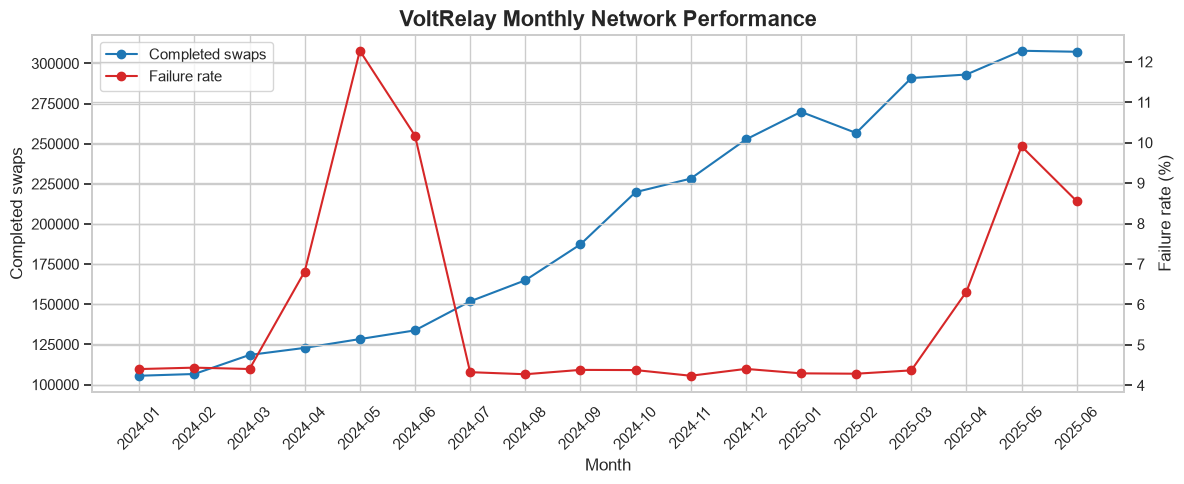

In [173]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(monthly_network["month"], monthly_network["completed_swaps"], marker="o", color="tab:blue", label="Completed swaps")
ax1.set_xlabel("Month")
ax1.set_ylabel("Completed swaps")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly_network["month"], monthly_network["failure_rate_pct"], marker="o", color="tab:red",label="Failure rate")
ax2.set_ylabel("Failure rate (%)")

lines = ax1.lines + ax2.lines
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("VoltRelay Monthly Network Performance", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [174]:
monthly_failures = (
    swap_events[swap_events["event_type"] != "swap_completed"]
    .groupby(["month", "event_type"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

display(monthly_failures)

event_type,month,abandoned_queue,cancelled_by_rider,failed_no_charged_battery,failed_system_error
0,2024-01,1405,445,2690,318
1,2024-02,1451,471,2681,346
2,2024-03,1575,549,2938,394
3,2024-04,2683,524,5382,393
4,2024-05,5520,670,11313,447
5,2024-06,4596,638,9452,459
6,2024-07,2025,653,3734,452
7,2024-08,2185,755,3955,469
8,2024-09,2442,830,4690,621
9,2024-10,2904,1011,5483,665


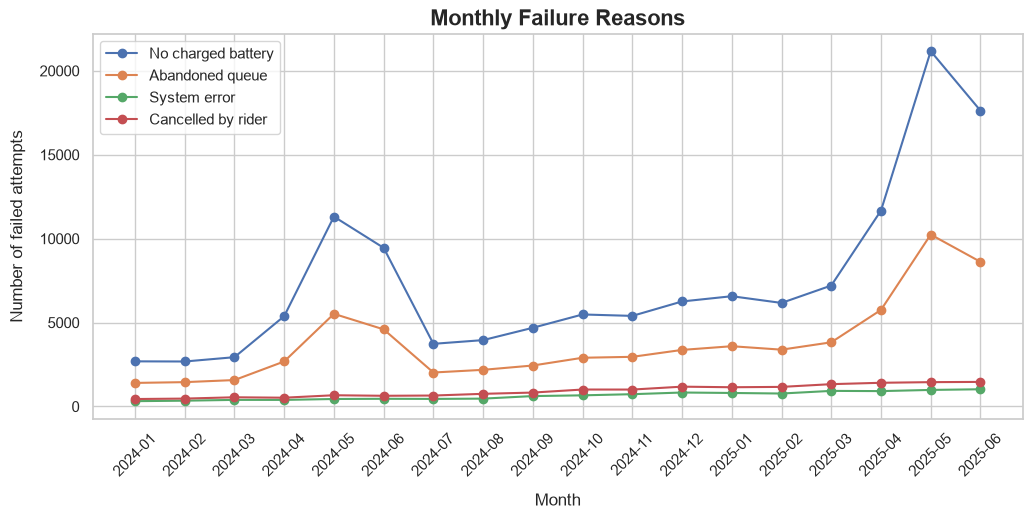

In [175]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_failures["month"], monthly_failures["failed_no_charged_battery"], marker="o", label="No charged battery")
plt.plot(monthly_failures["month"], monthly_failures["abandoned_queue"], marker="o", label="Abandoned queue")
plt.plot( monthly_failures["month"], monthly_failures["failed_system_error"], marker="o", label="System error")
plt.plot(monthly_failures["month"], monthly_failures["cancelled_by_rider"], marker="o", label="Cancelled by rider")

plt.xlabel("Month", labelpad=10)
plt.ylabel("Number of failed attempts", labelpad=10)
plt.title("Monthly Failure Reasons", fontsize=16, fontweight="bold")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [176]:
swap_city = swap_events.merge(stations[["station_id", "city"]], on="station_id", how="left", validate="many_to_one")

city_failure = (
    swap_city
    .groupby("city", observed=True)
    .agg(
        total_attempts=("event_id", "count"),
        completed_swaps=("event_type", lambda x: (x == "swap_completed").sum())
    )
    .reset_index()
)

city_failure["failed_attempts"] = (city_failure["total_attempts"] - city_failure["completed_swaps"])
city_failure["failure_rate_pct"] = (city_failure["failed_attempts"] / city_failure["total_attempts"] * 100)
city_failure = city_failure.sort_values("failure_rate_pct", ascending=False)

display(city_failure)

,city,total_attempts,completed_swaps,failed_attempts,failure_rate_pct
3,Jaipur,487634,449366,38268,7.847689
1,Delhi NCR,768913,712385,56528,7.351677
2,Hyderabad,711930,664312,47618,6.688579
5,Pune,552910,525331,27579,4.987973
0,Bengaluru,825327,787697,37630,4.559405
4,Mumbai,530299,506718,23581,4.446737


In [177]:
city_month_failure = (
    swap_city.groupby(["month", "city"], observed=True)
    .agg(
        total_attempts=("event_id", "count"),
        completed_swaps=("event_type", lambda x: (x == "swap_completed").sum())
    )
    .reset_index()
)

city_month_failure["failed_attempts"] = (city_month_failure["total_attempts"] - city_month_failure["completed_swaps"])
city_month_failure["failure_rate_pct"] = ( city_month_failure["failed_attempts"]/city_month_failure["total_attempts"] * 100)

display(
    city_month_failure[
        city_month_failure["month"].isin(["2024-04", "2024-05", "2024-06", "2024-07", "2025-04", "2025-05", "2025-06"])
    ]
    .sort_values(["month", "failure_rate_pct"], ascending=[True, False])
)

,month,city,total_attempts,completed_swaps,failed_attempts,failure_rate_pct
21,2024-04,Jaipur,16766,14501,2265,13.509483
19,2024-04,Delhi NCR,24352,21904,2448,10.052562
20,2024-04,Hyderabad,23871,22512,1359,5.693100
22,2024-04,Mumbai,19000,18143,857,4.510526
23,2024-04,Pune,19488,18631,857,4.397578
18,2024-04,Bengaluru,28341,27145,1196,4.220035
27,2024-05,Jaipur,18243,14637,3606,19.766486
26,2024-05,Hyderabad,26021,21410,4611,17.720303
25,2024-05,Delhi NCR,26706,22177,4529,16.958736
29,2024-05,Pune,22078,19912,2166,9.810671


In [178]:
station_failure = (swap_city.groupby(["station_id", "city"], observed=True)
    .agg(
        total_attempts=("event_id", "count"),
        completed_swaps=("event_type", lambda x: (x == "swap_completed").sum())
    )
    .reset_index()
)
station_failure["failed_attempts"] = (station_failure["total_attempts"] - station_failure["completed_swaps"])
station_failure["failure_rate_pct"] = (station_failure["failed_attempts"] / station_failure["total_attempts"] * 100)
station_failure = station_failure.sort_values("failure_rate_pct", ascending=False)
display(station_failure.head(20))

,station_id,city,total_attempts,completed_swaps,failed_attempts,failure_rate_pct
36,STN-DEL-037,Delhi NCR,30838,28039,2799,9.076464
47,STN-DEL-048,Delhi NCR,34646,31535,3111,8.979392
92,STN-JAI-137,Jaipur,44371,40490,3881,8.746704
97,STN-JAI-142,Jaipur,33319,30405,2914,8.745761
96,STN-JAI-141,Jaipur,45594,41613,3981,8.731412
44,STN-DEL-045,Delhi NCR,32237,29426,2811,8.719794
91,STN-JAI-136,Jaipur,29340,26785,2555,8.708248
93,STN-JAI-138,Jaipur,48945,44703,4242,8.666871
39,STN-DEL-040,Delhi NCR,40335,36848,3487,8.645097
49,STN-DEL-050,Delhi NCR,47060,43007,4053,8.612410


In [179]:
may_2024 = swap_city[swap_city["month"] == "2024-05"]

may_station_failure = (may_2024.groupby(["station_id", "city"], observed=True)
    .agg(
        total_attempts=("event_id", "count"),
        completed_swaps=("event_type", lambda x: (x == "swap_completed").sum())
    )
    .reset_index()
)
may_station_failure["failed_attempts"] = (may_station_failure["total_attempts"] - may_station_failure["completed_swaps"])
may_station_failure["failure_rate_pct"] = ( may_station_failure["failed_attempts"] / may_station_failure["total_attempts"] * 100)
may_station_failure = may_station_failure.sort_values("failure_rate_pct", ascending=False)

display(may_station_failure.head(20))

,station_id,city,total_attempts,completed_swaps,failed_attempts,failure_rate_pct
36,STN-DEL-049,Delhi NCR,1003,775,228,22.731805
60,STN-JAI-139,Jaipur,1645,1288,357,21.702128
47,STN-HYD-072,Hyderabad,2172,1714,458,21.086556
51,STN-HYD-076,Hyderabad,1065,842,223,20.938967
32,STN-DEL-045,Delhi NCR,1198,949,249,20.784641
35,STN-DEL-048,Delhi NCR,1381,1095,286,20.709631
26,STN-DEL-039,Delhi NCR,1429,1135,294,20.573828
62,STN-JAI-141,Jaipur,2230,1778,452,20.269058
59,STN-JAI-138,Jaipur,2189,1746,443,20.237551
23,STN-DEL-036,Delhi NCR,1301,1039,262,20.138355


In [180]:
station_meta = stations[
    [
        "station_id",
        "city",
        "location_type",
        "host_type",
        "expansion_wave",
        "charger_generation",
        "connectivity_tier",
        "firmware_version",
        "commissioned_date"
    ]
]

may_station_analysis = may_station_failure.merge(station_meta, on=["station_id", "city"], how="left", validate="many_to_one")

display(may_station_analysis.head(20))

,station_id,city,total_attempts,completed_swaps,failed_attempts,failure_rate_pct,location_type,host_type,expansion_wave,charger_generation,connectivity_tier,firmware_version,commissioned_date
0,STN-DEL-049,Delhi NCR,1003,775,228,22.731805,tech_park,fuel_retailer,Launch,Gen1,fair,v3.2.1,2023-11-10
1,STN-JAI-139,Jaipur,1645,1288,357,21.702128,commercial_hub,kirana,Launch,Gen1,poor,v3.2.1,2023-09-24
2,STN-HYD-072,Hyderabad,2172,1714,458,21.086556,commercial_hub,kirana,Launch,Gen1,good,v3.2.1,2023-06-08
3,STN-HYD-076,Hyderabad,1065,842,223,20.938967,transit_hub,mall_parking,Launch,Gen1,good,v3.2.1,2023-10-27
4,STN-DEL-045,Delhi NCR,1198,949,249,20.784641,commercial_hub,owned_lot,Launch,Gen1,good,v3.2.1,2023-06-07
5,STN-DEL-048,Delhi NCR,1381,1095,286,20.709631,market,owned_lot,Launch,Gen1,good,v3.2.0,2023-09-07
6,STN-DEL-039,Delhi NCR,1429,1135,294,20.573828,residential,fuel_retailer,Launch,Gen1,fair,v3.2.1,2023-11-25
7,STN-JAI-141,Jaipur,2230,1778,452,20.269058,commercial_hub,mall_parking,Launch,Gen1,good,v3.2.1,2023-06-06
8,STN-JAI-138,Jaipur,2189,1746,443,20.237551,market,kirana,Launch,Gen1,poor,v3.2.1,2023-08-26
9,STN-DEL-036,Delhi NCR,1301,1039,262,20.138355,market,fuel_retailer,Launch,Gen1,good,v3.2.1,2023-11-07


In [181]:
may_gen_analysis = (
    may_station_analysis.groupby("charger_generation", observed=True)
    .agg(
        total_attempts=("total_attempts", "sum"),
        completed_swaps=("completed_swaps", "sum"),
        failed_attempts=("failed_attempts", "sum")
    )
    .reset_index()
)

may_gen_analysis["failure_rate_pct"] = (may_gen_analysis["failed_attempts"] / may_gen_analysis["total_attempts"] * 100)
may_gen_analysis = may_gen_analysis.sort_values("failure_rate_pct", ascending=False)
display(may_gen_analysis)

,charger_generation,total_attempts,completed_swaps,failed_attempts,failure_rate_pct
0,Gen1,82542,68907,13635,16.518863
1,Gen2,63736,59421,4315,6.770114


In [182]:
may_firmware_analysis = (
    may_station_analysis
    .groupby("firmware_version", observed=True)
    .agg(
        total_attempts=("total_attempts", "sum"),
        completed_swaps=("completed_swaps", "sum"),
        failed_attempts=("failed_attempts", "sum")
    )
    .reset_index()
)

may_firmware_analysis["failure_rate_pct"] = (may_firmware_analysis["failed_attempts"] / may_firmware_analysis["total_attempts"] * 100)

display(may_firmware_analysis.sort_values("failure_rate_pct", ascending=False))

,firmware_version,total_attempts,completed_swaps,failed_attempts,failure_rate_pct
0,v3.2.0,59424,52115,7309,12.299744
1,v3.2.1,86854,76213,10641,12.251595


In [183]:
city_gen_analysis = (
    may_station_analysis.groupby(["city", "charger_generation"], observed=True)
    .agg(
        total_attempts=("total_attempts", "sum"),
        completed_swaps=("completed_swaps", "sum"),
        failed_attempts=("failed_attempts", "sum")
    )
    .reset_index()
)

city_gen_analysis["failure_rate_pct"] = (city_gen_analysis["failed_attempts"] / city_gen_analysis["total_attempts"] * 100)

display( city_gen_analysis.sort_values( ["city", "failure_rate_pct"], ascending=[True, False]))

,city,charger_generation,total_attempts,completed_swaps,failed_attempts,failure_rate_pct
0,Bengaluru,Gen1,13819,12798,1021,7.388378
1,Bengaluru,Gen2,18498,17438,1060,5.730349
2,Delhi NCR,Gen1,19284,15506,3778,19.591371
3,Delhi NCR,Gen2,7422,6671,751,10.118566
4,Hyderabad,Gen1,21209,17089,4120,19.425715
5,Hyderabad,Gen2,4812,4321,491,10.203658
6,Jaipur,Gen1,18243,14637,3606,19.766486
7,Mumbai,Gen1,3457,3277,180,5.206827
8,Mumbai,Gen2,17456,16679,777,4.451192
9,Pune,Gen1,6530,5600,930,14.241960


In [184]:
may_gen_failure_type = (
    may_station_analysis[["station_id", "city", "charger_generation"]]
    .merge(
        may_2024[["station_id", "event_type"]],
        on="station_id",
        how="inner"
    )
    .groupby(["charger_generation", "event_type"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

display(may_gen_failure_type)

event_type,charger_generation,abandoned_queue,cancelled_by_rider,failed_no_charged_battery,failed_system_error,swap_completed
0,Gen1,4228,382,8755,270,68907
1,Gen2,1292,288,2558,177,59421


In [185]:
station_hourly = pd.read_csv(
    DATA_PATH / "station_hourly_status.csv",
    parse_dates=["hour_start"],
    dtype={
        "station_id": "string",
        "charged_2w_avg": "float32",
        "charged_2w_min": "float32",
        "charged_3w_min": "float32",
        "packs_charging": "float32",
        "packs_quarantined": "float32",
        "chargers_online": "float32",
        "ambient_temp_c": "float32",
        "cabinet_temp_c": "float32",
        "avg_charge_minutes": "float32",
        "outage_minutes": "float32",
        "grid_kwh": "float32",
        "telemetry_status": "category"
    }
)

print(station_hourly.shape)
display(station_hourly.head())

(1487712, 14)


,station_id,hour_start,charged_2w_avg,charged_2w_min,charged_3w_min,packs_charging,packs_quarantined,chargers_online,ambient_temp_c,cabinet_temp_c,avg_charge_minutes,outage_minutes,grid_kwh,telemetry_status
0,STN-BLR-001,2024-01-01 00:00:00,6.29,6.0,4.0,1.0,0.0,18.0,8.2,13.5,92.599998,0.0,1.86,ok
1,STN-BLR-001,2024-01-01 01:00:00,8.10,8.0,4.0,8.0,0.0,18.0,8.2,11.5,88.000000,0.0,13.96,ok
2,STN-BLR-001,2024-01-01 02:00:00,10.56,8.0,4.0,5.0,0.0,18.0,8.2,12.9,80.199997,0.0,8.27,ok
3,STN-BLR-001,2024-01-01 03:00:00,7.44,6.0,3.0,5.0,0.0,18.0,8.2,13.2,86.699997,0.0,8.38,ok
4,STN-BLR-001,2024-01-01 04:00:00,9.18,7.0,3.0,3.0,0.0,18.0,8.2,14.0,83.900002,0.0,4.28,ok


In [186]:
id="p7x2md"
may_status = station_hourly[
    (station_hourly["hour_start"] >= "2024-05-01") &
    (station_hourly["hour_start"] < "2024-06-01")
].merge(
    stations[["station_id", "city", "charger_generation"]],
    on="station_id",
    how="left",
    validate="many_to_one"
)

may_status_gen = (
    may_status
    .groupby("charger_generation", observed=True)
    .agg(
        charged_2w_min_avg=("charged_2w_min", "mean"),
        charged_3w_min_avg=("charged_3w_min", "mean"),
        packs_charging_avg=("packs_charging", "mean"),
        packs_quarantined_avg=("packs_quarantined", "mean"),
        chargers_online_avg=("chargers_online", "mean"),
        avg_charge_minutes=("avg_charge_minutes", "mean"),
        outage_minutes=("outage_minutes", "sum")
    )
    .reset_index()
)

display(may_status_gen)

,charger_generation,charged_2w_min_avg,charged_3w_min_avg,packs_charging_avg,packs_quarantined_avg,chargers_online_avg,avg_charge_minutes,outage_minutes
0,Gen1,5.743587,1.865644,4.616560,0.004452,15.474857,110.201149,420.0
1,Gen2,7.452469,2.751912,4.187678,0.002843,14.081989,65.085655,240.0


In [187]:
city_gen_status = (
    may_status
    .groupby(["city", "charger_generation"], observed=True)
    .agg(
        charged_2w_min_avg=("charged_2w_min", "mean"),
        charged_3w_min_avg=("charged_3w_min", "mean"),
        avg_charge_minutes=("avg_charge_minutes", "mean"),
        outage_minutes=("outage_minutes", "sum")
    )
    .reset_index()
)

display(city_gen_status.sort_values( ["city", "charger_generation"]))

,city,charger_generation,charged_2w_min_avg,charged_3w_min_avg,avg_charge_minutes,outage_minutes
0,Bengaluru,Gen1,6.105808,2.294086,90.814552,60.0
1,Bengaluru,Gen2,6.489749,2.671186,64.433502,120.0
2,Delhi NCR,Gen1,5.240874,1.715591,121.680550,120.0
3,Delhi NCR,Gen2,5.981774,3.198925,68.070076,60.0
4,Hyderabad,Gen1,5.613830,1.850075,107.846443,0.0
5,Hyderabad,Gen2,7.258961,3.233871,66.616356,0.0
6,Jaipur,Gen1,5.088547,1.732939,126.218330,120.0
7,Mumbai,Gen1,7.536963,1.508065,88.643341,60.0
8,Mumbai,Gen2,7.996428,3.096853,64.105873,60.0
9,Pune,Gen1,7.698925,1.362903,95.359543,60.0


In [188]:
pricing_analysis = (swap_events.groupby(["month", "tariff_code"], observed=True)
    .agg(
        attempts=("event_id", "count"),
        completed_swaps=("event_type", lambda x: (x == "swap_completed").sum()),
        list_price=("list_price_inr", "mean"),
        discount=("discount_inr", "mean"),
        amount_charged=("amount_charged_inr", "mean")
    )
    .reset_index()
)

display(pricing_analysis)

,month,tariff_code,attempts,completed_swaps,list_price,discount,amount_charged
0,2024-01,PARTNER,74381,70941,65.756310,6.823054,55.959724
1,2024-01,STD,35967,34549,62.552341,0.000000,59.962048
2,2024-02,PARTNER,75099,71676,65.800873,6.845186,56.020653
3,2024-02,STD,36432,34906,62.584541,0.000000,59.851780
4,2024-03,PARTNER,82826,79087,65.737328,6.847642,55.980755
5,2024-03,STD,41074,39357,62.542728,0.000000,59.817768
6,2024-04,PARTNER,87411,81390,65.890335,6.848635,54.758850
7,2024-04,STD,44407,41446,62.456371,0.000000,58.182945
8,2024-05,PARTNER,96770,84885,65.808823,6.836288,51.561684
9,2024-05,STD,49508,43443,62.297001,0.000000,54.536034


In [189]:
swap_events.loc[
    (swap_events["month"].isin(["2025-05", "2025-06"])) &
    (swap_events["tariff_code"] == "PARTNER"),
    ["event_type", "amount_charged_inr"]
    
].groupby("event_type").agg(
    count=("event_type", "size"),
    avg_amount=("amount_charged_inr", "mean")
)

,count,avg_amount
event_type,,
abandoned_queue,12587,0.000000
cancelled_by_rider,1950,0.000000
failed_no_charged_battery,25750,0.000000
failed_system_error,1320,0.000000
swap_completed,405146,62.238014


In [190]:
completed_swaps = swap_city[
    swap_city["event_type"] == "swap_completed"].merge(
    stations[
        [
            "station_id",
            "grid_tariff_inr_kwh",
            "monthly_rent_inr",
            "monthly_maintenance_inr"
        ]
    ],
    on="station_id",
    how="left",
    validate="many_to_one"
)

completed_swaps["electricity_cost_inr"] = (completed_swaps["energy_to_recharge_kwh"] * completed_swaps["grid_tariff_inr_kwh"])

station_month = (
    completed_swaps
    .groupby(["month", "station_id"], observed=True)
    .agg(
        completed_swaps=("event_id", "count"),
        revenue_inr=("amount_charged_inr", "sum"),
        electricity_cost_inr=("electricity_cost_inr", "sum"),
        monthly_rent_inr=("monthly_rent_inr", "first"),
        monthly_maintenance_inr=("monthly_maintenance_inr", "first")
    )
    .reset_index()
)

station_month["allocated_fixed_cost_inr"] = (
    station_month["monthly_rent_inr"] +
    station_month["monthly_maintenance_inr"]
)

station_month["contribution_margin_inr"] = (
    station_month["revenue_inr"]
    - station_month["electricity_cost_inr"]
    - station_month["allocated_fixed_cost_inr"]
)

monthly_margin = (
    station_month
    .groupby("month", observed=True)
    .agg(
        completed_swaps=("completed_swaps", "sum"),
        revenue_inr=("revenue_inr", "sum"),
        electricity_cost_inr=("electricity_cost_inr", "sum"),
        fixed_cost_inr=("allocated_fixed_cost_inr", "sum"),
        contribution_margin_inr=("contribution_margin_inr", "sum")
    )
    .reset_index()
)

monthly_margin["margin_per_swap_inr"] = (
    monthly_margin["contribution_margin_inr"] /
    monthly_margin["completed_swaps"]
)

display(monthly_margin)

,month,completed_swaps,revenue_inr,electricity_cost_inr,fixed_cost_inr,contribution_margin_inr,margin_per_swap_inr
0,2024-01,105490,6318995.0,2.320971e+06,2143096,1.854928e+06,17.583922
1,2024-02,106582,6387615.0,2.334290e+06,2143096,1.910228e+06,17.922617
2,2024-03,118444,7093617.0,2.572347e+06,2143096,2.378174e+06,20.078471
3,2024-04,122836,7370256.0,2.652599e+06,2143096,2.574561e+06,20.959335
4,2024-05,128328,7689594.0,2.738029e+06,2143096,2.808469e+06,21.885082
5,2024-06,133743,8003275.5,2.813406e+06,2143096,3.046774e+06,22.780808
6,2024-07,151824,9879525.0,3.166310e+06,2143096,4.570119e+06,30.101425
7,2024-08,164931,10724297.0,3.405336e+06,2405333,4.913627e+06,29.792019
8,2024-09,187302,12115209.0,3.830746e+06,2582737,5.701727e+06,30.441355
9,2024-10,219838,14577272.0,4.444667e+06,2880895,7.251710e+06,32.986608


In [191]:
swap_events["hour"] = swap_events["event_ts"].dt.hour

hourly_cx = (swap_events.groupby("hour", observed=True)
    .agg(
        total_attempts=("event_id", "count"),
        completed_swaps=("event_type", lambda x: (x == "swap_completed").sum()),
        abandoned_queue=("event_type", lambda x: (x == "abandoned_queue").sum()),
        avg_queue_wait_sec=("queue_wait_sec", "mean"),
        median_queue_wait_sec=("queue_wait_sec", "median")
    )
    .reset_index()
)
hourly_cx["failure_rate_pct"] = ( (hourly_cx["total_attempts"] - hourly_cx["completed_swaps"]) / hourly_cx["total_attempts"] * 100)
hourly_cx["abandonment_rate_pct"] = (hourly_cx["abandoned_queue"] / hourly_cx["total_attempts"] * 100)
display(hourly_cx)

,hour,total_attempts,completed_swaps,abandoned_queue,avg_queue_wait_sec,median_queue_wait_sec,failure_rate_pct,abandonment_rate_pct
0,0,23043,21768,378,243.871761,207.0,5.533134,1.640411
1,1,23482,22190,399,245.071374,207.0,5.502087,1.699174
2,2,25536,24094,417,242.593828,207.0,5.646930,1.632989
3,3,28822,27309,476,243.604226,206.0,5.249462,1.651516
4,4,31193,29603,467,241.425480,206.0,5.097297,1.497131
5,5,28510,26990,475,243.668608,206.0,5.331463,1.666082
6,6,62020,58626,1009,242.690487,206.0,5.472428,1.626895
7,7,66889,63248,1110,243.696064,206.0,5.443346,1.659466
8,8,171129,161445,2894,242.903079,206.0,5.658889,1.691122
9,9,232933,219890,3851,242.609617,206.0,5.599464,1.653265


In [192]:
rider_vehicle = riders[ ["rider_id", "vehicle_class"] ]
vehicle_cx = swap_events.merge( rider_vehicle, on="rider_id", how="left", validate="many_to_one")

vehicle_cx = (vehicle_cx.groupby("vehicle_class", observed=True)
    .agg(
        total_attempts=("event_id", "count"),
        completed_swaps=("event_type", lambda x: (x == "swap_completed").sum()),
        abandoned_queue=("event_type", lambda x: (x == "abandoned_queue").sum()),
        avg_queue_wait_sec=("queue_wait_sec", "mean"),
        median_queue_wait_sec=("queue_wait_sec", "median")
    )
    .reset_index()
)

vehicle_cx["failure_rate_pct"] = ( (vehicle_cx["total_attempts"] - vehicle_cx["completed_swaps"]) / vehicle_cx["total_attempts"] * 100)
vehicle_cx["abandonment_rate_pct"] = (vehicle_cx["abandoned_queue"] / vehicle_cx["total_attempts"] * 100)
display(vehicle_cx)

,vehicle_class,total_attempts,completed_swaps,abandoned_queue,avg_queue_wait_sec,median_queue_wait_sec,failure_rate_pct,abandonment_rate_pct
0,2W,3452996,3265675,54881,242.973286,206.0,5.424883,1.589373
1,3W,424017,380134,13652,242.793272,203.0,10.349349,3.219682


In [193]:
battery_cols = batteries[ ["battery_id", "supplier", "manufacturing_lot", "initial_soh_pct", "current_soh_pct"] ]

battery_swaps = completed_swaps[ ["battery_out_id", "soh_out_clean", "km_since_last_swap"]].merge(
    battery_cols,
    left_on="battery_out_id",
    right_on="battery_id",
    how="left",
    validate="many_to_one"
)

battery_summary = (battery_swaps.groupby("supplier", observed=True).agg(
        swaps=("battery_id", "count"),
        avg_soh=("soh_out_clean", "mean"),
        avg_km_since_swap=("km_since_last_swap", "mean"),
        avg_current_soh=("current_soh_pct", "mean")
    )
    .reset_index().sort_values("avg_soh")
)
display(battery_summary)

,supplier,swaps,avg_soh,avg_km_since_swap,avg_current_soh
2,Kyron,657648,82.018120,56.775509,63.649744
1,Cellora,2188677,89.808937,63.071651,80.573657
0,Amptek,799484,89.835335,63.307056,80.616474


In [194]:
completed_events = swap_events[swap_events["event_type"] == "swap_completed"].copy()

first_swaps = (
    completed_events
    .sort_values("event_ts")
    .groupby("rider_id", observed=True)
    .first()
    .reset_index()
)

first_swaps = first_swaps[
    [
        "rider_id",
        "event_ts",
        "station_id",
        "queue_wait_sec",
        "km_since_last_swap",
        "tariff_code",
        "list_price_inr",
        "discount_inr",
        "amount_charged_inr",
        "energy_to_recharge_kwh",
        "soh_in_clean"
    ]
]

first_swaps = first_swaps.rename( columns={"event_ts": "first_swap_ts"} )
display(first_swaps.head())
print("New riders:", len(first_swaps))

,rider_id,first_swap_ts,station_id,queue_wait_sec,km_since_last_swap,tariff_code,list_price_inr,discount_inr,amount_charged_inr,energy_to_recharge_kwh,soh_in_clean
0,RD-1000000,2024-01-03 10:51:42,STN-DEL-037,251,92.800003,PARTNER,100.0,8.0,92.000000,4.867,99.400002
1,RD-1000001,2024-01-03 12:43:26,STN-MUM-123,100,86.400002,PARTNER,60.0,6.6,53.400002,2.128,99.500000
2,RD-1000002,2024-01-03 09:24:12,STN-HYD-068,207,62.099998,PARTNER,60.0,3.6,56.400002,2.027,99.900002
3,RD-1000003,2024-01-01 11:10:56,STN-MUM-115,88,80.400002,PARTNER,60.0,6.0,54.000000,2.035,100.000000
4,RD-1000004,2024-01-01 17:13:06,STN-HYD-070,148,66.099998,PARTNER,60.0,9.0,51.000000,2.157,98.300003


New riders: 19948


In [195]:
support_summary = (
    support_tickets
    .groupby("category", observed=True)
    .agg(
        tickets=("ticket_id", "count"),
        avg_resolution_hours=("resolution_hours", "mean"),
        avg_csat=("csat_score", "mean")
    )
    .reset_index()
    .sort_values("tickets", ascending=False)
)

display(support_summary)

,category,tickets,avg_resolution_hours,avg_csat
4,no_battery_available,11647,15.961265,3.602452
5,other,9484,16.036723,3.567468
3,low_range,6636,15.990958,3.531183
0,app_issue,5787,15.894224,3.539805
2,long_queue,5731,15.842201,3.506520
1,billing_dispute,4715,15.908325,3.569136


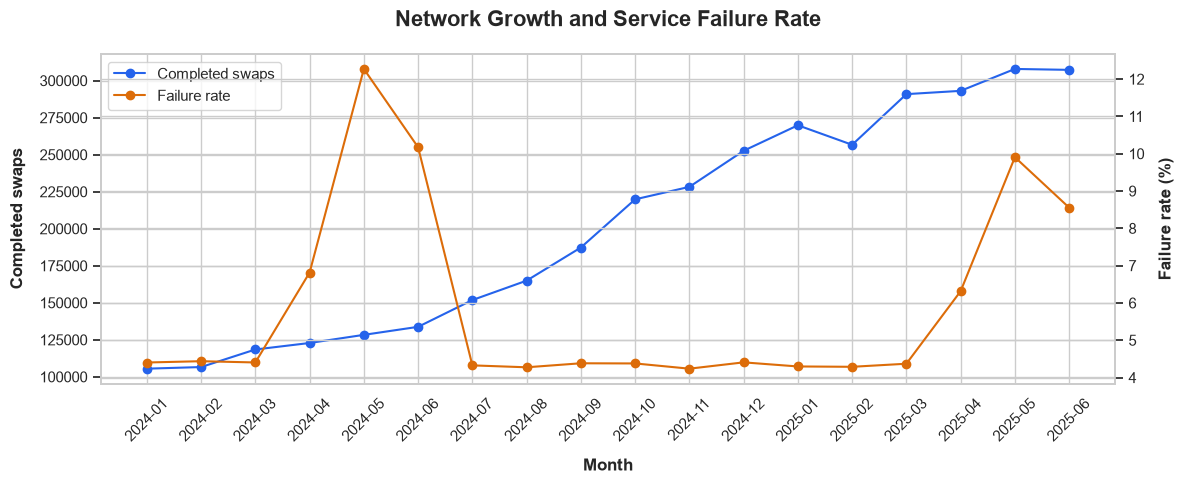

In [196]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(monthly_network["month"], monthly_network["completed_swaps"], marker="o", color="#2563EB", label="Completed swaps")
ax1.set_xlabel("Month", labelpad=10, fontsize=12, fontweight="bold")
ax1.set_ylabel("Completed swaps", labelpad=10, fontsize=12, fontweight="bold")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly_network["month"], monthly_network["failure_rate_pct"], marker="o", color="#DC6C09", label="Failure rate" )
ax2.set_ylabel("Failure rate (%)", labelpad=10, fontsize=12, fontweight="bold")

lines = ax1.lines + ax2.lines
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("Network Growth and Service Failure Rate", fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("../outputs/figures/01_network_growth_failure_rate.png", dpi=300, bbox_inches="tight")
plt.show()

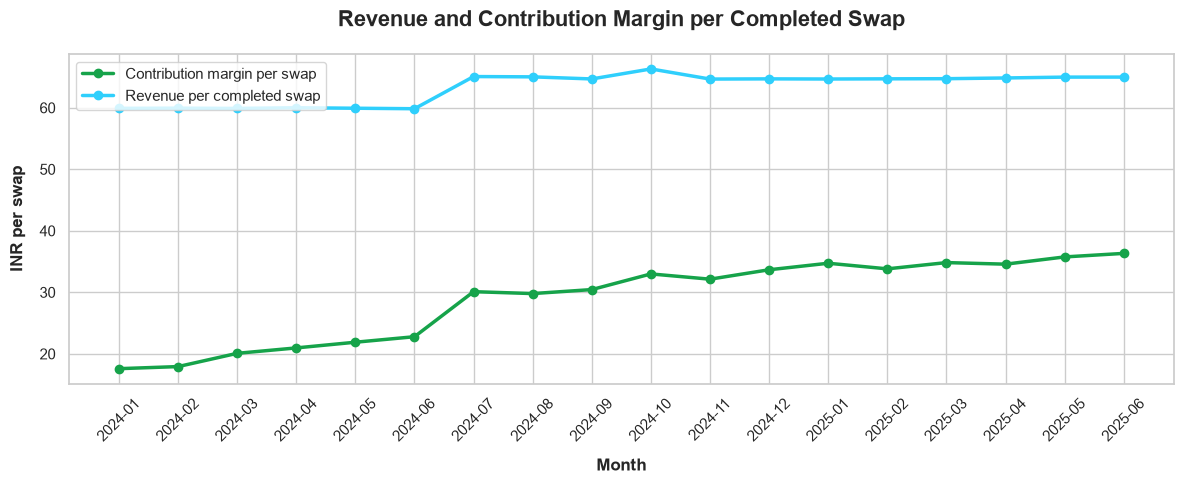

In [197]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    monthly_margin["month"],
    monthly_margin["margin_per_swap_inr"],
    marker="o", color="#16A34A", linewidth=2.5, label="Contribution margin per swap")

ax.plot(
    monthly_network["month"],
    monthly_network["avg_revenue_per_completed_swap"],
    marker="o", color="#2FCFFC", linewidth=2.5, label="Revenue per completed swap")

ax.set_xlabel("Month", labelpad=10, fontsize=12, fontweight="bold")
ax.set_ylabel("INR per swap", labelpad=10, fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper left")

plt.title("Revenue and Contribution Margin per Completed Swap", fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("../outputs/figures/02_revenue_contribution_margin.png", dpi=300, bbox_inches="tight")
plt.show()

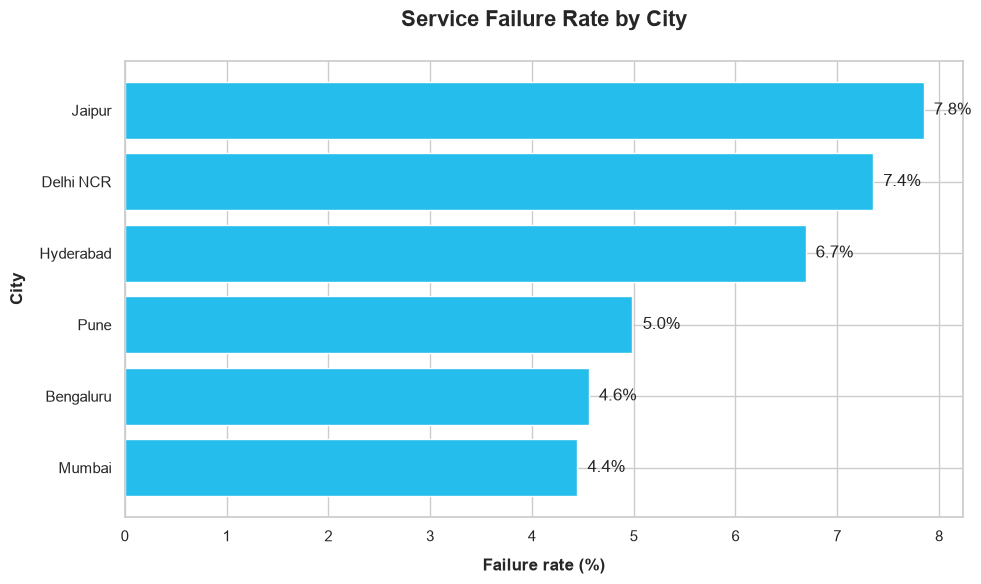

In [198]:
city_plot = city_failure.sort_values("failure_rate_pct", ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(city_plot["city"], city_plot["failure_rate_pct"], color="#25BDEB")

ax.set_xlabel("Failure rate (%)", labelpad=10, fontsize=12, fontweight="bold")
ax.set_ylabel("City", labelpad=10, fontsize=12, fontweight="bold")
ax.set_title("Service Failure Rate by City", fontsize=16, fontweight="bold", pad=25)

for bar in bars:
    width = bar.get_width()
    ax.text( width + 0.1, bar.get_y() + bar.get_height() / 2, f"{width:.1f}%", va="center")

plt.tight_layout()
plt.savefig("../outputs/figures/03_city_failure_rate.png", dpi=300, bbox_inches="tight")
plt.show()

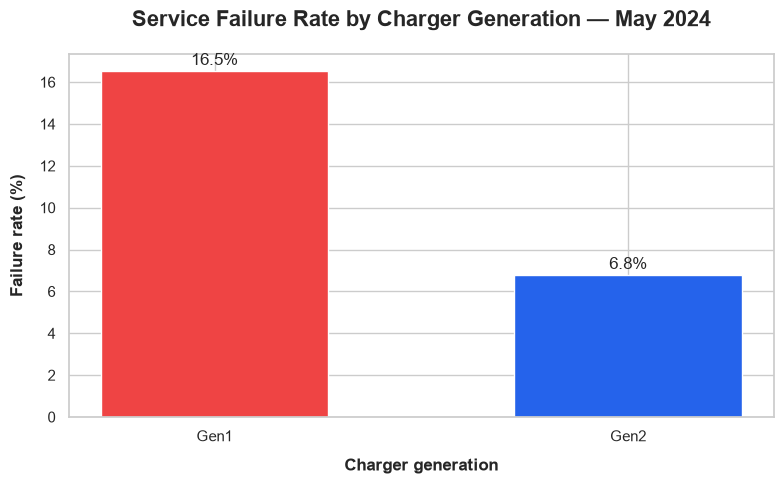

In [199]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(may_gen_analysis["charger_generation"], may_gen_analysis["failure_rate_pct"], color=["#EF4444", "#2563EB"], width=0.55)

ax.set_xlabel("Charger generation", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("Failure rate (%)", fontsize=12, fontweight="bold", labelpad=10)
ax.set_title("Service Failure Rate by Charger Generation — May 2024", fontsize=16, fontweight="bold", pad=20)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,
        f"{height:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.savefig("../outputs/figures/04_gen1_vs_gen2_failure_rate.png", dpi=300, bbox_inches="tight")
plt.show()

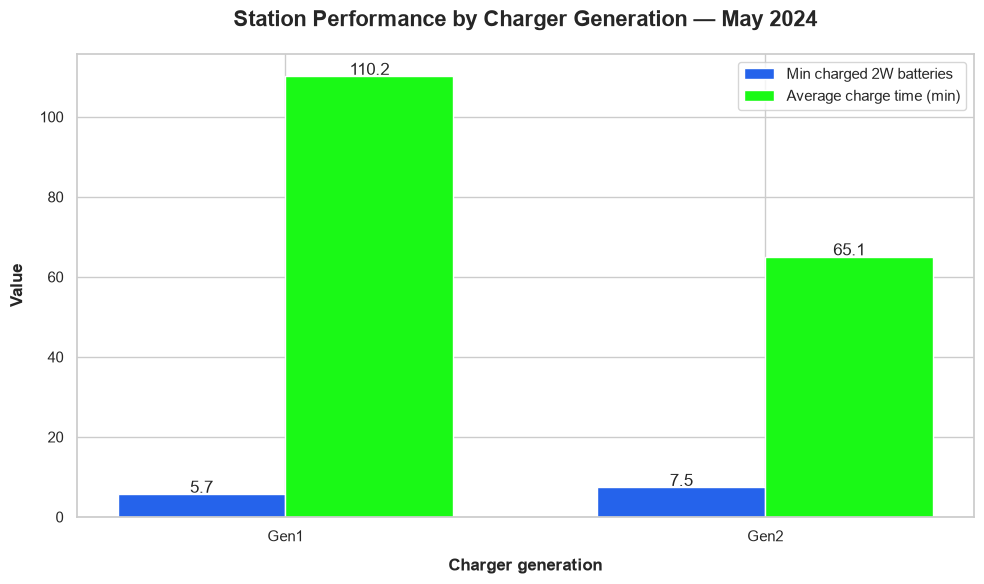

In [200]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(may_status_gen))
width = 0.35

bars1 = ax.bar(x - width / 2, may_status_gen["charged_2w_min_avg"], width, color="#2563EB", label="Min charged 2W batteries")
bars2 = ax.bar( x + width / 2, may_status_gen["avg_charge_minutes"], width, color="#1AF916", label="Average charge time (min)")

ax.set_xlabel( "Charger generation", fontsize=12, fontweight="bold", labelpad=10 )
ax.set_ylabel( "Value", fontsize=12, fontweight="bold", labelpad=10)
ax.set_title("Station Performance by Charger Generation — May 2024", fontsize=16, fontweight="bold", pad=20)
ax.set_xticks(x)
ax.set_xticklabels(may_status_gen["charger_generation"])

ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.3,
            f"{height:.1f}",
            ha="center"
        )

plt.tight_layout()
plt.savefig("../outputs/figures/05_gen1_vs_gen2_station_performance.png", dpi=600, bbox_inches="tight")
plt.show()

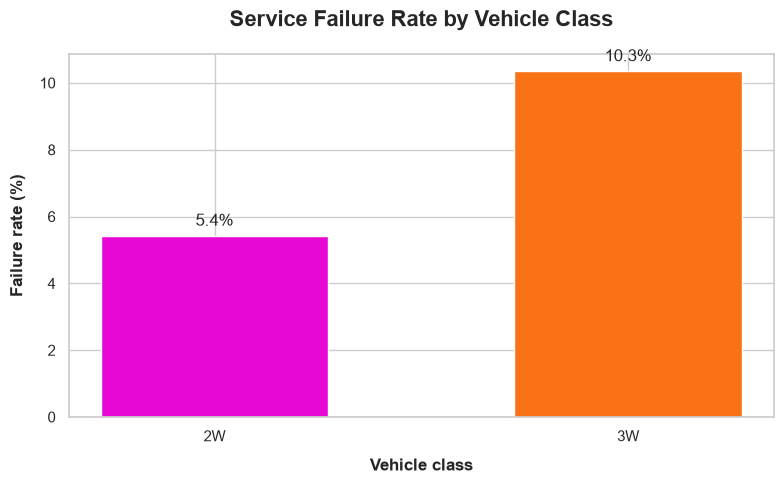

In [201]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(vehicle_cx["vehicle_class"], vehicle_cx["failure_rate_pct"], color=["#E808D6", "#F97316"], width=0.55)
ax.set_xlabel("Vehicle class", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("Failure rate (%)",  fontsize=12, fontweight="bold", labelpad=10)
ax.set_title( "Service Failure Rate by Vehicle Class", fontsize=16, fontweight="bold", pad=20)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, height + 0.3, f"{height:.1f}%", ha="center"
    )

plt.tight_layout()
plt.savefig("../outputs/figures/06_vehicle_class_failure_rate.png", dpi=600, bbox_inches="tight")
plt.show()

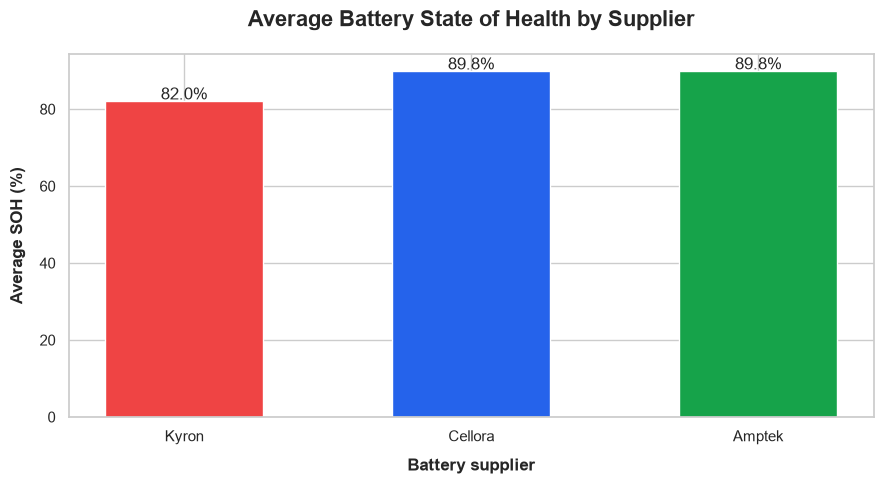

In [202]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar( battery_summary["supplier"],  battery_summary["avg_soh"], color=["#EF4444", "#2563EB", "#16A34A"], width=0.55)
ax.set_xlabel("Battery supplier", fontsize=12,  fontweight="bold", labelpad=10)
ax.set_ylabel( "Average SOH (%)", fontsize=12, fontweight="bold", labelpad=10)
ax.set_title("Average Battery State of Health by Supplier", fontsize=16, fontweight="bold",  pad=20)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f"{height:.1f}%", ha="center")

plt.tight_layout()
plt.savefig("../outputs/figures/07_battery_supplier_soh.png", dpi=600, bbox_inches="tight")
plt.show()

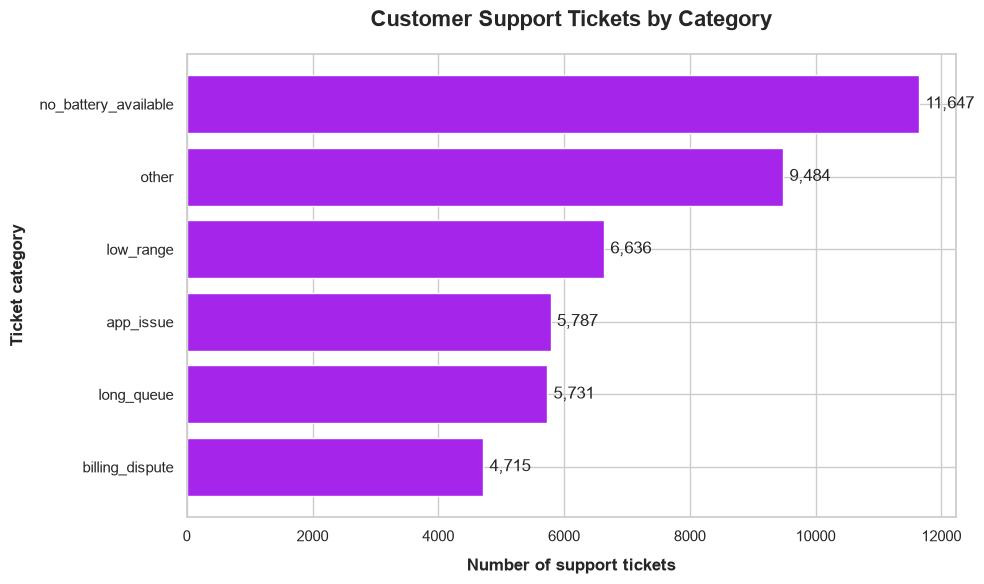

In [203]:
fig, ax = plt.subplots(figsize=(10, 6))

support_plot = support_summary.sort_values("tickets", ascending=True)
bars = ax.barh( support_plot["category"], support_plot["tickets"], color="#A625EB")
ax.set_xlabel( "Number of support tickets", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel( "Ticket category",  fontsize=12,  fontweight="bold",  labelpad=10)
ax.set_title( "Customer Support Tickets by Category",  fontsize=16, fontweight="bold", pad=20)

for bar in bars:
    width = bar.get_width()
    ax.text( width + 100,  bar.get_y() + bar.get_height() / 2, f"{int(width):,}", va="center")

plt.tight_layout()
plt.savefig(  "../outputs/figures/08_support_ticket_categories.png", dpi=600, bbox_inches="tight")
plt.show()